# 02 — Preprocess CDFG JSON → PyG tensors


In [10]:
%load_ext autoreload
%autoreload 2

In [25]:
from ll_hls4ml.config import load_config
from ll_hls4ml.data.tensorize import create_graph_tensors
from ll_hls4ml.data.vocab import save_vocab, vocab_scan, load_vocab, make_local_types_global
from ll_hls4ml.viz.dataset import analyze_graph_dataset
from ll_hls4ml.viz.eda import plot_vocab_counts


In [29]:
cfg = load_config()

kernel_subset = ["2layer"]  # extend as needed
max_archives = 1

In [28]:
from ll_hls4ml.io.discovery import iter_graph_paths
import tqdm
from pathlib import Path

graph_dir = cfg.graph_dir
paths = list(iter_graph_paths(graph_dir, kernel_subset, max_archives))

for i in tqdm.tqdm(range(len(paths)), desc="Parsing graph files for building vocab"):
    graph_path = paths[i][1]
    ll_path = str(graph_path).replace("graphs", "ll").replace(".json", ".ll")
    new_graph_path = Path(str(graph_path).replace("archive_4", "archive_1"))
    new_graph_path.parent.mkdir(parents=True, exist_ok=True)
    make_local_types_global(graph_path, ll_path, new_graph_path)
    

Parsing graph files for building vocab:   0%|          | 0/100 [00:00<?, ?it/s]

Parsing graph files for building vocab: 100%|██████████| 100/100 [01:33<00:00,  1.07it/s]


Parsing graph files for building vocab: 100%|██████████| 100/100 [00:07<00:00, 12.78it/s]


Credit for /home/brend/projects/data/graphs/2layer/archive_1/01ffd896-3ffb-4676-99db-aec59732aa32.json (number 1)
  instruction: ['[external]', 'alloca', 'br', 'phi', 'invoke', 'getelementptr', 'icmp', 'call', 'ret', 'landingpad', 'extractvalue', 'store', 'load', 'insertvalue', 'resume', 'bitcast', '; undefined function', 'trunc', 'unreachable', 'add', 'sext', 'shl', 'ashr', 'ptrtoint', 'sub', 'zext', 'select', 'and', 'lshr', 'or', 'xor', 'urem', 'mul']
  variable: ['ap_fixed<2, 1, (ap_q_mode)5, (ap_o_mode)3, 0>*', 'i1', '{ i8*, i32 }', 'i8*', 'i8**', 'i32', 'i32*', 'ap_fixed<2, 1, (ap_q_mode)5, (ap_o_mode)3, 0>**', 'ap_fixed_base<2, 1, true, (ap_q_mode)5, (ap_o_mode)3, 0>*', 'ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>**', 'i8', '[64 x ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>]*', 'ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>*', '%"class.std::allocator"*', '%"class.std::allocator"**', '%"class.std::__new_allocator"*', '%"class.std::__new_allocator"**', '%"class.std::__cxx11:

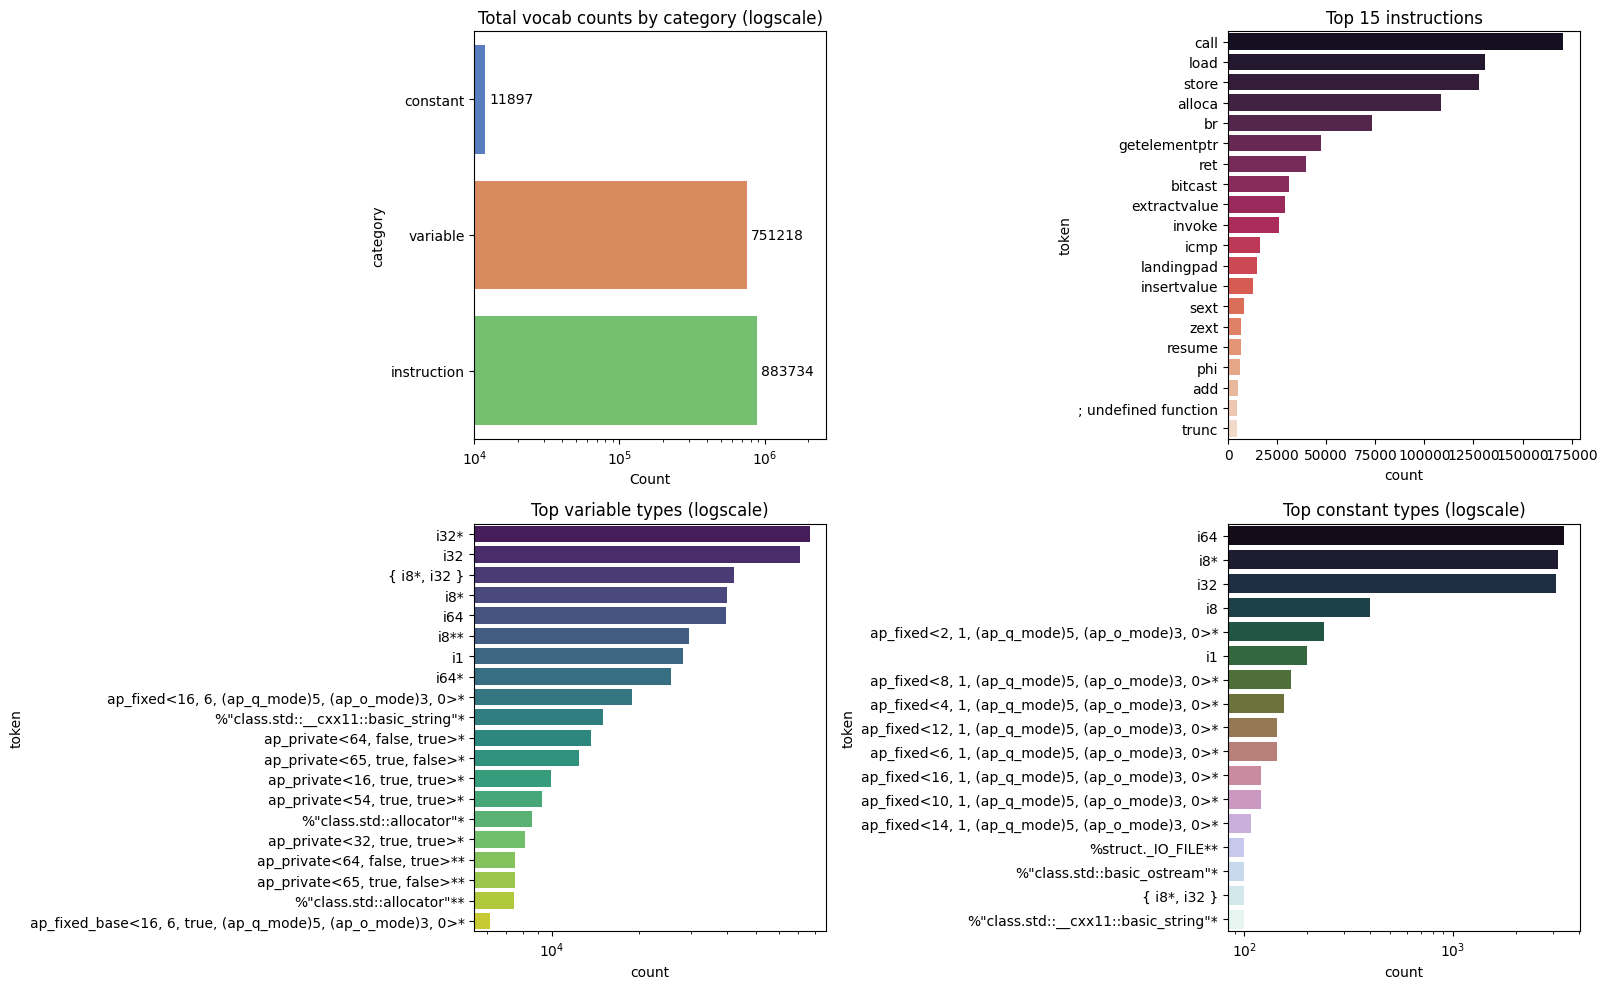

{'constant': {'%"class.std::__cxx11::basic_string"*': 1,
              '%"class.std::basic_ostream"*': 2,
              '%struct._IO_FILE**': 3,
              'UNK': 0,
              'ap_fixed<10, 1, (ap_q_mode)5, (ap_o_mode)3, 0>*': 4,
              'ap_fixed<12, 1, (ap_q_mode)5, (ap_o_mode)3, 0>*': 5,
              'ap_fixed<14, 1, (ap_q_mode)5, (ap_o_mode)3, 0>*': 6,
              'ap_fixed<16, 1, (ap_q_mode)5, (ap_o_mode)3, 0>*': 7,
              'ap_fixed<2, 1, (ap_q_mode)5, (ap_o_mode)3, 0>*': 8,
              'ap_fixed<4, 1, (ap_q_mode)5, (ap_o_mode)3, 0>*': 9,
              'ap_fixed<6, 1, (ap_q_mode)5, (ap_o_mode)3, 0>*': 10,
              'ap_fixed<8, 1, (ap_q_mode)5, (ap_o_mode)3, 0>*': 11,
              'i1': 12,
              'i32': 13,
              'i64': 14,
              'i8': 15,
              'i8*': 16,
              '{ i8*, i32 }': 17},
 'instruction': {'; undefined function': 1,
                 'UNK': 0,
                 '[external]': 2,
                 'add': 3,

In [30]:
vocab, max_pos, vocab_counts, _, _ = vocab_scan(
    cfg.graph_dir, kernel_subset=kernel_subset, max_archives=max_archives
)
save_vocab(vocab, "./artifacts/vocab/new_vocab.json", max_pos=max_pos, vocab_counts=vocab_counts)
vocab, max_pos, vocab_counts = load_vocab("./artifacts/vocab/new_vocab.json")
plot_vocab_counts(vocab_counts)
from pprint import pprint
pprint(vocab)
print(max_pos)
pprint(vocab_counts)
